In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nexuswho/laboro-tomato")

print("Path to dataset files:", path)

Path to dataset files: /home/tim/.cache/kagglehub/datasets/nexuswho/laboro-tomato/versions/5


In [4]:
#show dataset structure
import os
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 4 * (level + 1)
    if (files):
        print(f"{subindent}example: {files[0]}")


5/
    example: example_dataset.yaml
    train/
        labels/
            example: IMG_1140.txt
        images/
            example: IMG_20191215_111316.jpg
    val/
        labels/
            example: IMG_0986.txt
        images/
            example: IMG_20191215_110708.jpg
    annotations/
        example: train.json


In [5]:
#read     example_dataset.yaml
import yaml
with open(os.path.join(path, "example_dataset.yaml"), 'r') as file:
    dataset_info = yaml.safe_load(file)
print(dataset_info)

{'names': ['b_fully_ripened', 'b_half_ripened', 'b_green', 'l_fully_ripened', 'l_half_ripened', 'l_green'], 'nc': 6, 'path': 'D:\\Datasets\\laboro_tomato', 'train': 'train\\images', 'val': 'val\\images'}


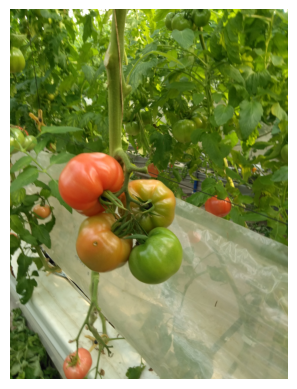

In [6]:
#view image from train/images
import cv2
import matplotlib.pyplot as plt
test_image_path = "/home/tim/.cache/kagglehub/datasets/nexuswho/laboro-tomato/versions/5/train/images/IMG_20191215_111316.jpg"

image = cv2.imread(test_image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)
plt.axis('off')
plt.show()

In [ ]:
# change .yaml file


In [11]:
from ultralytics import YOLO

model = YOLO('yolo11n.pt')
model.train(
    data="dataset.yaml",
    epochs=5, 
    imgsz=640
)

Ultralytics 8.4.38 🚀 Python-3.10.20 torch-2.4.1+cpu CPU (Intel Core i7-5600U 2.60GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train5, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78eb9d5aca60>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

In [34]:
from ultralytics import YOLO
import cv2

# 1. Load YOUR trained model
model = YOLO('runs/detect/train/weights/best.pt') 

# 2. Run detection on an image from your 'val' set
# Change this path to a real image in your val folder
results = model.predict(source='/home/tim/.cache/kagglehub/datasets/nexuswho/laboro-tomato/versions/5/train/images/IMG_20191215_111316.jpg', save=True, conf=0.50)


image 1/1 /home/tim/.cache/kagglehub/datasets/nexuswho/laboro-tomato/versions/5/train/images/IMG_20191215_111316.jpg: 640x480 2 b_fully_ripeneds, 4 b_half_ripeneds, 12 b_greens, 153.6ms
Speed: 7.4ms preprocess, 153.6ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /home/tim/LearnigOpencv/TomatoTracker/runs/detect/predict


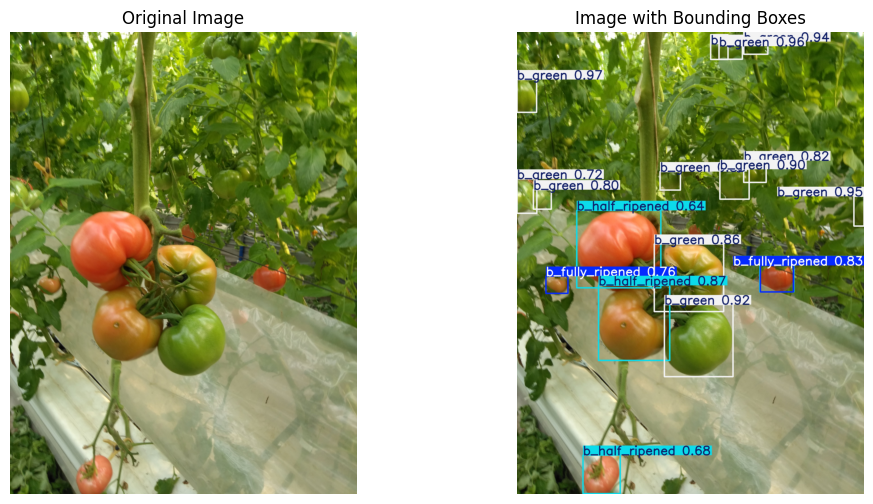

Number of detected objects: 18
b_green: 12
b_half_ripened: 4
b_fully_ripened: 2


In [36]:
#display original image next to the image with bounding boxes
original_image = cv2.imread('/home/tim/.cache/kagglehub/datasets/nexuswho/laboro-tomato/versions/5/train/images/IMG_20191215_111316.jpg')
original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
bbox_image = cv2.imread(results[0].save_dir + '/' + results[0].path.split('/')[-1])
bbox_image = cv2.cvtColor(bbox_image, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(original_image)
plt.axis('off')
plt.subplot(1, 2, 2)
plt.title("Image with Bounding Boxes")
plt.imshow(bbox_image)
plt.axis('off')
plt.show()

#print count of detected objects sorted by class name
print(f"Number of detected objects: {len(results[0].boxes)}")
from collections import Counter
class_counts = Counter(results[0].boxes.cls.cpu().numpy())
for cls, count in class_counts.items():
    class_name = model.names[int(cls)]
    print(f"{class_name}: {count}")

In [47]:
from ultralytics import YOLO

# 1. Load your trained model
model = YOLO('runs/detect/train/weights/best.pt')

# 2. Run validation (this is the "Automatic Test")
results = model.val() # It automatically uses the 'val' path from your .yaml

# 3. Print the main accuracy metric
print(f"Mean Average Precision (mAP50): {results.box.map50:.3f}")

Ultralytics 8.4.38 🚀 Python-3.10.20 torch-2.4.1+cpu CPU (Intel Core i7-5600U 2.60GHz)
YOLO11n summary (fused): 101 layers, 2,583,322 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4082.4±236.7 MB/s, size: 2431.2 KB)
val: Scanning /home/tim/.cache/kagglehub/datasets/nexuswho/laboro-tomato/versions/5/val/labels.cache... 161 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 161/161 35.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 3.4s/it 37.9s3.5s
                   all        161       1996      0.577      0.711      0.607      0.474
       b_fully_ripened         40         72      0.435      0.819      0.466      0.374
        b_half_ripened         52        116      0.496      0.737      0.571      0.442
               b_green         71        387      0.683      0.841      0.841      0.659
       l_fully_ripened         59        269      0.571      0.743      0.

In [48]:
# 3. Data for the chart
# We'll map the class names to their actual counts in the validation set
class_names = model.names
ground_truth_counts = results.confusion_matrix.matrix.sum(axis=1)[:-1] # Sum of rows
predicted_counts = results.confusion_matrix.matrix.sum(axis=0)[:-1]    # Sum of columns

In [51]:
import pandas as pd
# 4. Create a DataFrame for easier plotting
df = pd.DataFrame({
    'Stage': [class_names[i] for i in range(len(ground_truth_counts))],
    'Actual Yield (Labels)': ground_truth_counts,
    'Predicted Yield (AI)': predicted_counts
})

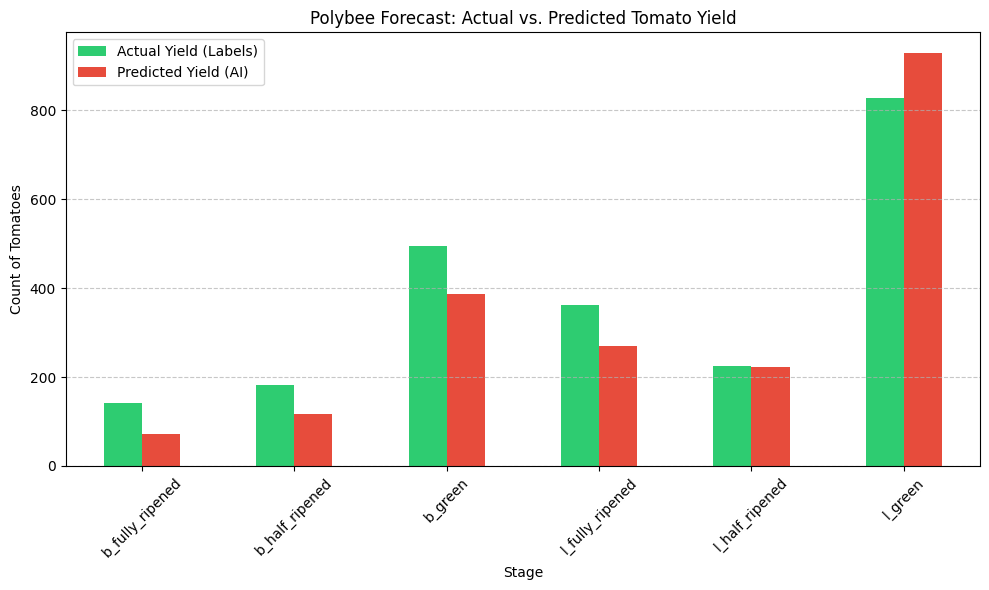

In [52]:

# 5. Plotting
df.set_index('Stage').plot(kind='bar', figsize=(10, 6), color=['#2ecc71', '#e74c3c'])
plt.title('Polybee Forecast: Actual vs. Predicted Tomato Yield')
plt.ylabel('Count of Tomatoes')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


image 1/1 /home/tim/LearnigOpencv/TomatoTracker/test_image.jpg: 640x480 1 b_fully_ripened, 2 l_fully_ripeneds, 2 l_greens, 135.8ms
Speed: 5.2ms preprocess, 135.8ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /home/tim/LearnigOpencv/TomatoTracker/runs/detect/predict2

--- HARVEST FORECAST ---
Ripe Now (Harvest today): 3 units detected
Half-Ripe (Harvest in 3-5 days): 0 units detected
Green (Harvest in 10-14 days): 2 units detected

Estimated Ripe Yield: 0.45 kg
------------------------------------



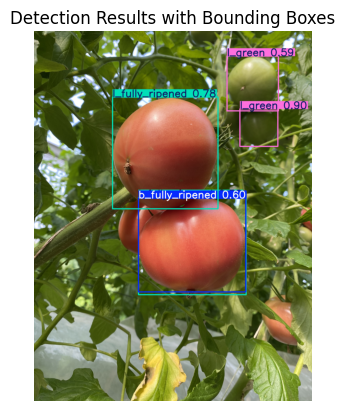

In [67]:
results = model.predict(source='test_image.jpg', save=True, conf=0.5)
# 3. Create a logic to count and estimate
stats = {
    'Ripe Now (Harvest today)': 0,
    'Half-Ripe (Harvest in 3-5 days)': 0,
    'Green (Harvest in 10-14 days)': 0
}

for r in results:
    for box in r.boxes:
        cls_id = int(box.cls[0])
        label = model.names[cls_id]
        
        # Mapping your classes to Farmer Logic
        if 'fully_ripened' in label:
            stats['Ripe Now (Harvest today)'] += 1
        elif 'half_ripened' in label:
            stats['Half-Ripe (Harvest in 3-5 days)'] += 1
        elif 'green' in label:
            stats['Green (Harvest in 10-14 days)'] += 1

# 4. Display the "Polybee Executive Summary"
print("\n--- HARVEST FORECAST ---")
for stage, count in stats.items():
    print(f"{stage}: {count} units detected")

# 5. Simple Estimate (Assuming average tomato weight = 150g)
ripe_weight = (stats['Ripe Now (Harvest today)'] * 0.150)
print(f"\nEstimated Ripe Yield: {ripe_weight:.2f} kg")
print("------------------------------------\n")
#show saved image with bounding boxes
bbox_image = cv2.imread(results[0].save_dir + '/' + results[0].path.split('/')[-1])
bbox_image = cv2.cvtColor(bbox_image, cv2.COLOR_BGR2RGB)
plt.imshow(bbox_image)
plt.axis('off')
plt.title("Detection Results with Bounding Boxes")
plt.show()